Pearson r:  0.791
Spearman p: 0.819


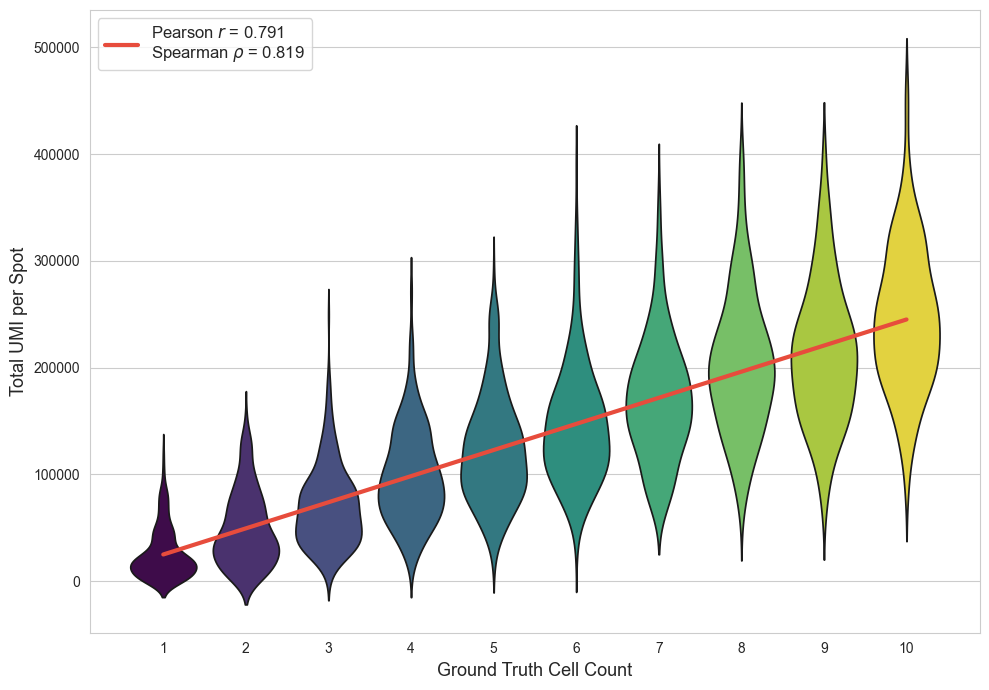

In [6]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, linregress
import matplotlib.lines as mlines

# 1. Load Ground Truth
gt = pd.read_csv("ground_truth_counts.csv")

# 2. Extract Total UMI from the local .h5
h5_path = 'filtered_feature_bc_matrix.h5' 

with h5py.File(h5_path, 'r') as f:
    barcodes = [b.decode('utf-8') for b in f['matrix']['barcodes'][:]]
    data = f['matrix']['data'][:]
    indptr = f['matrix']['indptr'][:]
    
    total_umi = []
    for i in range(len(barcodes)):
        start, end = indptr[i], indptr[i+1]
        total_umi.append(np.sum(data[start:end]))

umi_df = pd.DataFrame({'Spot': barcodes, 'Total_UMI': total_umi})

# 3. Merge based on the Spot ID
df = pd.merge(gt, umi_df, on='Spot')

# 4. Calculate Stats
x = df['True_Cells'].values
y = df['Total_UMI'].values

r_val, _ = pearsonr(x, y)
rho_val, _ = spearmanr(x, y)
slope, intercept, _, _, _ = linregress(x, y)

print(f"Pearson r:  {r_val:.3f}")
print(f"Spearman p: {rho_val:.3f}")

# 5. Generate Clean Violin Plot
sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))

# Create the Violin Plot - inner=None removes median/quartile lines
ax = sns.violinplot(
    data=df, 
    x='True_Cells', 
    y='Total_UMI', 
    inner=None, 
    palette="viridis", 
    hue='True_Cells',
    legend=False,
    density_norm="width"
)

# 6. Add Pearson Regression Line
# Note: x-axis in violin plots is treated as discrete indices 0, 1, 2...
unique_x = np.sort(df['True_Cells'].unique())
x_indices = np.arange(len(unique_x))
y_line = slope * unique_x + intercept

plt.plot(x_indices, y_line, color='#e74c3c', linewidth=3, zorder=5, label='Pearson Line')

# 7. Custom Legend
stats_label = (f'Pearson $r$ = {r_val:.3f}\n'
               f'Spearman $\\rho$ = {rho_val:.3f}')

# Use a proxy for the red line in the legend
red_line = mlines.Line2D([], [], color='#e74c3c', linewidth=3, label=stats_label)
plt.legend(handles=[red_line], loc='upper left', frameon=True, fontsize=12)

# Labels
plt.xlabel("Ground Truth Cell Count", fontsize=13)
plt.ylabel("Total UMI per Spot", fontsize=13)

plt.tight_layout()
plt.savefig("Baseline_UMI_Violin_Benchmark.png", dpi=600)
plt.show()